In [3]:
# -------------3 Kepler's Third Law------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [4]:
#3
df = pd.read_csv("../../course_assignments/homework9/solar_system.csv")
df

,Attribute,Mercury,Venus,Earth,Moon,Mars,Jupiter,Saturn,Uranus,Neptune,Pluto
0,Mass (10^24kg),0.330,4.87,5.97,0.073,0.642,1898,568,86.8,102,0.0130
1,Diameter (km),4879,12104,12756,3475,6792,142984,120536,51118,49528,2376
2,Density (kg/m^3),5429,5243,5514,3340,3934,1326,687,1270,1638,1850
3,Gravity (m/s^2),3.7,8.9,9.8,1.6,3.7,23.1,9.0,8.7,11.0,0.7
4,Escape Velocity (km/s),4.3,10.4,11.2,2.4,5.0,59.5,35.5,21.3,23.5,1.3
5,Rotation Period (hours),1407.6,-5832.5,23.9,655.7,24.6,9.9,10.7,-17.2,16.1,-153.3
6,Length of Day (hours),4222.6,2802.0,24.0,708.7,24.7,9.9,10.7,17.2,16.1,153.3
7,Distance from Sun (10^6 km),57.9,108.2,149.6,0.384,228.0,778.5,1432.0,2867.0,4515.0,5906.4
8,Perihelion (10^6 km),46.0,107.5,147.1,0.363,206.7,740.6,1357.6,2732.7,4471.1,4436.8
9,Aphelion (10^6 km),69.8,108.9,152.1,0.406,249.3,816.4,1506.5,3001.4,4558.9,7375.9


In [5]:
#4
shape = df.shape
print("Number of Columns: ", shape[1])   
print("Number of Rows: ", shape[0])
print("Column names:", df.columns)

Number of Columns:  11
Number of Rows:  20
Column names: Index(['Attribute', 'Mercury', 'Venus', 'Earth', 'Moon', 'Mars', 'Jupiter',
       'Saturn', 'Uranus', 'Neptune', 'Pluto'],
      dtype='object')


In [7]:
df.head()

,Attribute,Mercury,Venus,Earth,Moon,Mars,Jupiter,Saturn,Uranus,Neptune,Pluto
0,Mass (10^24kg),0.330,4.87,5.97,0.073,0.642,1898,568,86.8,102,0.0130
1,Diameter (km),4879,12104,12756,3475,6792,142984,120536,51118,49528,2376
2,Density (kg/m^3),5429,5243,5514,3340,3934,1326,687,1270,1638,1850
3,Gravity (m/s^2),3.7,8.9,9.8,1.6,3.7,23.1,9.0,8.7,11.0,0.7
4,Escape Velocity (km/s),4.3,10.4,11.2,2.4,5.0,59.5,35.5,21.3,23.5,1.3


In [8]:
df.tail()

,Attribute,Mercury,Venus,Earth,Moon,Mars,Jupiter,Saturn,Uranus,Neptune,Pluto
15,Mean Temperature (C),167,464,15,-20,-65,-110,-140,-195,-200,-225
16,Surface Pressure (bars),0,92,1,0,0.01,Unknown,Unknown,Unknown,Unknown,0.00001
17,Number of Moons,0,0,1,0,2,95,274,28,16,5
18,Ring System?,No,No,No,No,No,Yes,Yes,Yes,Yes,No
19,Global Magnetic Field?,Yes,No,Yes,No,No,Yes,Yes,Yes,Yes,Unknown


In [53]:
#5
Perihelion= df.iloc[[8], 1:10].astype(float)
Aphelion= df.iloc[[9], 1:10 ].astype(float)
Orbitable_period = df.iloc[[10],1:10].astype(float)

#6
#Perihelion: when the object is the closest in its orbit to its sun
#Aphelion: when the object is the farthest in its orbit to its sun
#Semi-Major Axis: the radius of the longest distance of the orbit

#7
semi_major_axis = pd.DataFrame((Perihelion.values+ Aphelion.values) / 2, columns=Perihelion.columns) 

#8
new_df = pd.concat([Perihelion, Aphelion, Orbitable_period, semi_major_axis], axis =0)
new_df

,Mercury,Venus,Earth,Moon,Mars,Jupiter,Saturn,Uranus,Neptune
8,46.0,107.5,147.1,0.3630,206.7,740.6,1357.60,2732.70,4471.1
9,69.8,108.9,152.1,0.4060,249.3,816.4,1506.50,3001.40,4558.9
10,88.0,224.7,365.2,27.3000,687.0,4331.0,10747.00,30589.00,59800.0
0,57.9,108.2,149.6,0.3845,228.0,778.5,1432.05,2867.05,4515.0


shape = new_df.shape
print("Number of Columns: ", shape[1])   
print("Number of Rows: ", shape[0])
print("Column names:", df.columns)

In [100]:
#9
shape = new_df.shape 
print("Number of Columns: ", shape[1])
print("Number of Rows: ", shape[0]) 
print("Column names:", df.columns)

Number of Columns:  9
Number of Rows:  4
Column names: Index(['Attribute', 'Mercury', 'Venus', 'Earth', 'Moon', 'Mars', 'Jupiter',
       'Saturn', 'Uranus', 'Neptune', 'Pluto'],
      dtype='object')


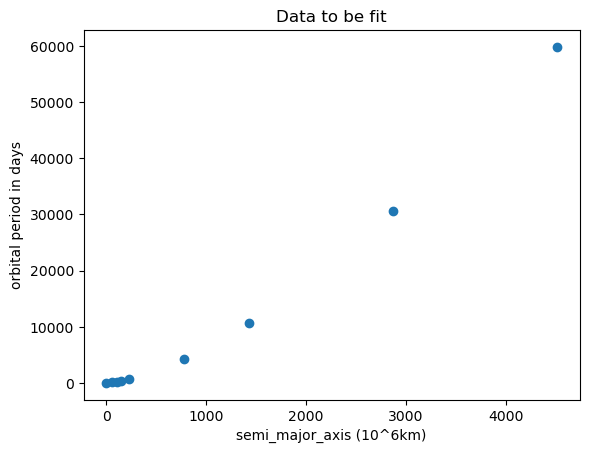

In [58]:
#10
plt.title('Data to be fit')
plt.xlabel('semi_major_axis (10^6km)')
plt.ylabel('orbital period in days')


plt.scatter(semi_major_axis, Orbitable_period,)

plt.show()

In [94]:
#11
def keplers_third_law(a, m):
    return m * a **1.5

x_data = semi_major_axis.squeeze()
y_data = Orbitable_period.squeeze()

#12
popt, pcov = curve_fit(keplers_third_law, x_data, y_data, p0=[1])

#13
m_fit = popt[0]
print(f"Line of Best Fit: y = {m_fit:.2f} * x^1.5")

#14
#15
residuals = y_data - keplers_third_law(x_data, m_fit)
chi2 = np.sum(residuals**2)
dof = len(x_data) - len(popt)
chi2_reduced = chi2 / dof

Line of Best Fit: y = 0.20 * x^1.5


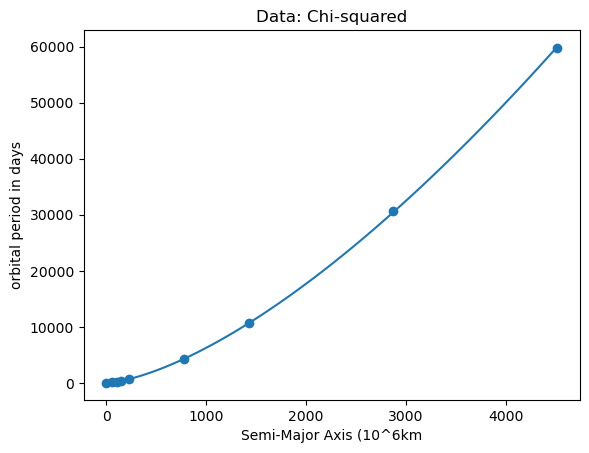

In [87]:
#16
plt.scatter(semi_major_axis, Orbitable_period,)
plt.title('Data: Chi-squared')
plt.plot(np.linspace(x_data.min(), x_data.max(), 100), m_fit * np.linspace(x_data.min(), x_data.max(), 100) **1.5)
plt.xlabel("Semi-Major Axis (10^6km")
plt.ylabel('orbital period in days')
plt.show()


In [98]:
#17
csv_filename = 'kepler.csv'

new_df.to_csv(csv_filename, index = False)